In [13]:
import numpy as np
import gzip
import pickle

In [14]:
def load_mnist():

    with gzip.open("mnist.pkl.gz", "rb") as f:
        train_set, valid_set, test_set = pickle.load(f, encoding="latin1")

    X_train, y_train = train_set
    X_test, y_test = test_set

    return X_train, y_train, X_test, y_test

In [15]:
def one_hot(y):

    onehot = np.zeros((y.size, 10))
    onehot[np.arange(y.size), y] = 1

    return onehot

In [16]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)
def softmax(x):

    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [17]:
class NeuralNetwork:

    def __init__(self, input_size, hidden_size, output_size):

        # Xavier initialization
        self.W1 = np.random.randn(input_size, hidden_size) / np.sqrt(input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) / np.sqrt(hidden_size)
        self.b2 = np.zeros((1, output_size))


    def forward(self, X):

        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2


    def backward(self, X, Y, lr):

        m = X.shape[0]

        dZ2 = self.A2 - Y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= lr * dW1
        self.b1 -= lr * db1

        self.W2 -= lr * dW2
        self.b2 -= lr * db2

In [20]:
def predict(nn, X):

    probs = nn.forward(X)
    return np.argmax(probs, axis=1)

In [19]:
def accuracy(nn, X, y):

    preds = predict(nn, X)
    return np.mean(preds == y)

In [22]:
X_train, y_train, X_test, y_test = load_mnist()

y_train_oh = one_hot(y_train)

nn = NeuralNetwork(784, 128, 10)

epochs = 50
lr = 0.01
batch_size = 64

for epoch in range(epochs):

    indices = np.random.permutation(X_train.shape[0])

    X_train = X_train[indices]
    y_train_oh = y_train_oh[indices]

    for i in range(0, X_train.shape[0], batch_size):

        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_oh[i:i+batch_size]

        nn.forward(X_batch)
        nn.backward(X_batch, y_batch, lr)

    acc = accuracy(nn, X_test, y_test)

    print("Epoch:", epoch, "Test Accuracy:", acc)

Epoch: 0 Test Accuracy: 0.8741
Epoch: 1 Test Accuracy: 0.8956
Epoch: 2 Test Accuracy: 0.9056
Epoch: 3 Test Accuracy: 0.9119
Epoch: 4 Test Accuracy: 0.9173
Epoch: 5 Test Accuracy: 0.9201
Epoch: 6 Test Accuracy: 0.9228
Epoch: 7 Test Accuracy: 0.9247
Epoch: 8 Test Accuracy: 0.9277
Epoch: 9 Test Accuracy: 0.9309
Epoch: 10 Test Accuracy: 0.9343
Epoch: 11 Test Accuracy: 0.9345
Epoch: 12 Test Accuracy: 0.9362
Epoch: 13 Test Accuracy: 0.9382
Epoch: 14 Test Accuracy: 0.9397
Epoch: 15 Test Accuracy: 0.9408
Epoch: 16 Test Accuracy: 0.9428
Epoch: 17 Test Accuracy: 0.9447
Epoch: 18 Test Accuracy: 0.9452
Epoch: 19 Test Accuracy: 0.947
Epoch: 20 Test Accuracy: 0.9479
Epoch: 21 Test Accuracy: 0.9483
Epoch: 22 Test Accuracy: 0.9502
Epoch: 23 Test Accuracy: 0.9512
Epoch: 24 Test Accuracy: 0.9523
Epoch: 25 Test Accuracy: 0.9538
Epoch: 26 Test Accuracy: 0.9543
Epoch: 27 Test Accuracy: 0.9547
Epoch: 28 Test Accuracy: 0.9555
Epoch: 29 Test Accuracy: 0.9563
Epoch: 30 Test Accuracy: 0.957
Epoch: 31 Test Accur

In [23]:
import matplotlib.pyplot as plt

In [26]:
def visualize_predictions(nn, X, y, num_images=10):

    predictions = predict(nn, X)

    for i in range(num_images):

        image = X[i].reshape(28, 28)

        plt.imshow(image, cmap="gray")
        plt.title(f"Prediction: {predictions[i]}  |  True: {y[i]}")
        plt.axis("off")
        plt.savefig(f"mnist_prediction_{i}.png", bbox_inches='tight')
        plt.show()

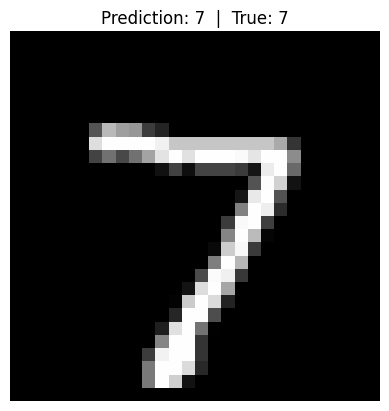

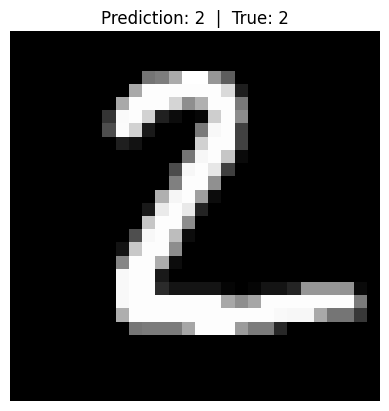

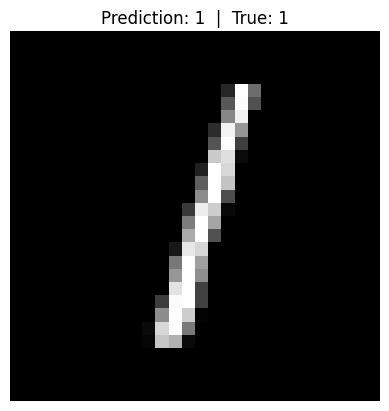

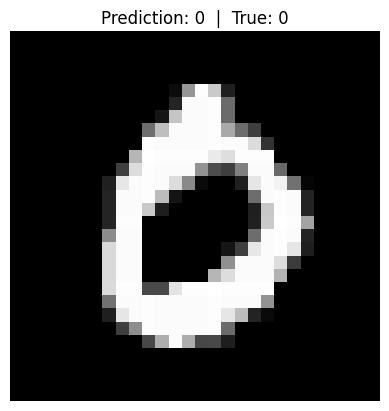

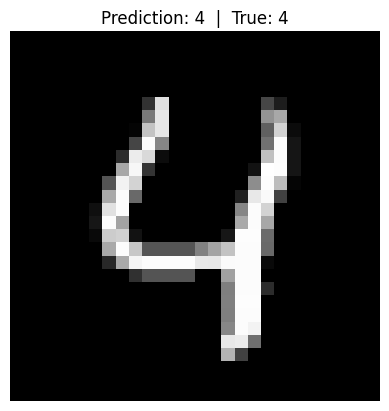

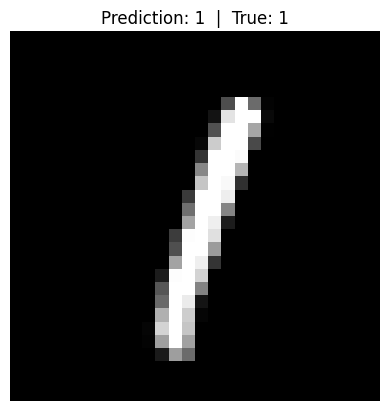

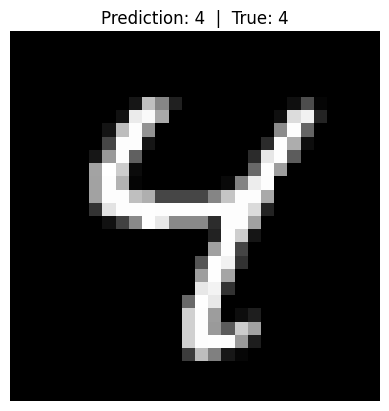

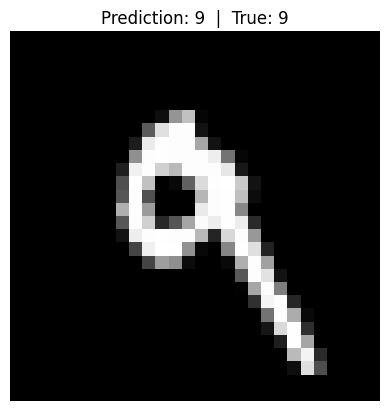

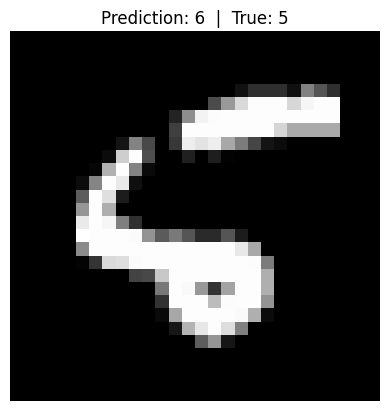

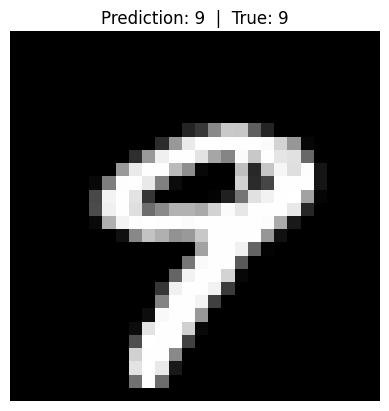

In [27]:
visualize_predictions(nn, X_test, y_test, 10)